# Project 3: Multivariate Data Visualization

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from math import pi

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from pandas.plotting import parallel_coordinates

from ucimlrepo import fetch_ucirepo
  
# fetch dataset
wine_quality = fetch_ucirepo(id=186)
  
# data (as pandas dataframes)
X = wine_quality.data.features
y = wine_quality.data.targets
  
# metadata
print(wine_quality.metadata)
  
# variable information
print(wine_quality.variables)

{'uci_id': 186, 'name': 'Wine Quality', 'repository_url': 'https://archive.ics.uci.edu/dataset/186/wine+quality', 'data_url': 'https://archive.ics.uci.edu/static/public/186/data.csv', 'abstract': 'Two datasets are included, related to red and white vinho verde wine samples, from the north of Portugal. The goal is to model wine quality based on physicochemical tests (see [Cortez et al., 2009], http://www3.dsi.uminho.pt/pcortez/wine/).', 'area': 'Business', 'tasks': ['Classification', 'Regression'], 'characteristics': ['Multivariate'], 'num_instances': 4898, 'num_features': 11, 'feature_types': ['Real'], 'demographics': [], 'target_col': ['quality'], 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 2009, 'last_updated': 'Wed Nov 15 2023', 'dataset_doi': '10.24432/C56S3T', 'creators': ['Paulo Cortez', 'A. Cerdeira', 'F. Almeida', 'T. Matos', 'J. Reis'], 'intro_paper': {'ID': 252, 'type': 'NATIVE', 'title': 'Modeling wine preferences

In [2]:
X = wine_quality.data.features.copy()
X["color"] = wine_quality.data.original["color"]
df = pd.concat([X, y], axis=1)
df.head()

,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,color,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,red,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,red,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,red,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,red,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,red,5


## Visualizations

### Visualization 1: Scatterplot

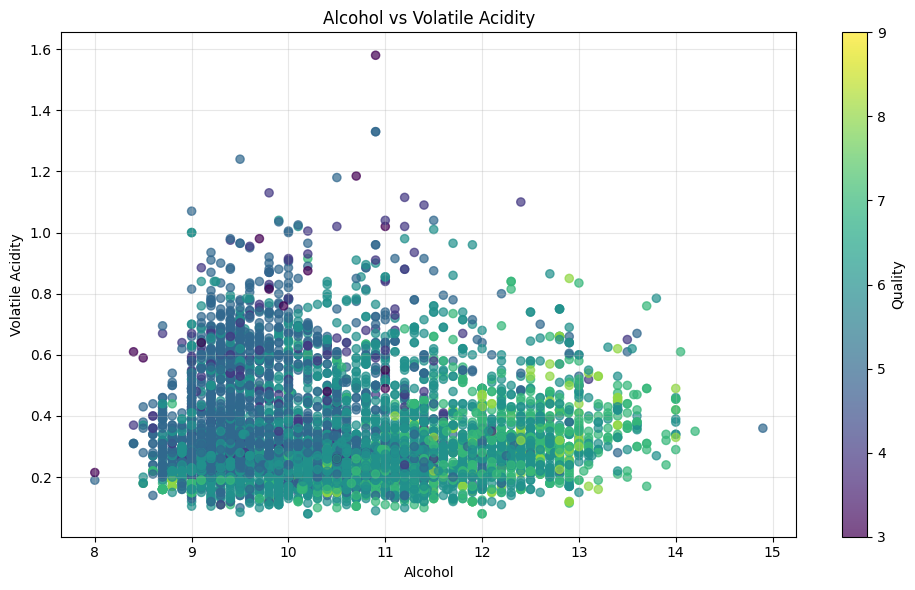

In [3]:
plt.figure(figsize=(10, 6))

scatter = plt.scatter(
    df["alcohol"],
    df["volatile_acidity"],
    c=df["quality"],
    alpha=0.7,
    s=35
)

plt.title("Alcohol vs Volatile Acidity")
plt.xlabel("Alcohol")
plt.ylabel("Volatile Acidity")
plt.colorbar(scatter, label="Quality")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Visualization 2: Stacked Bar Chart

## Extra Visualizations

/var/folders/7j/xlk59hmx1nvdzrt98s82gl6w0000gn/T/ipykernel_38957/3258000794.py:34: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(min(200, len(x)), random_state=42))


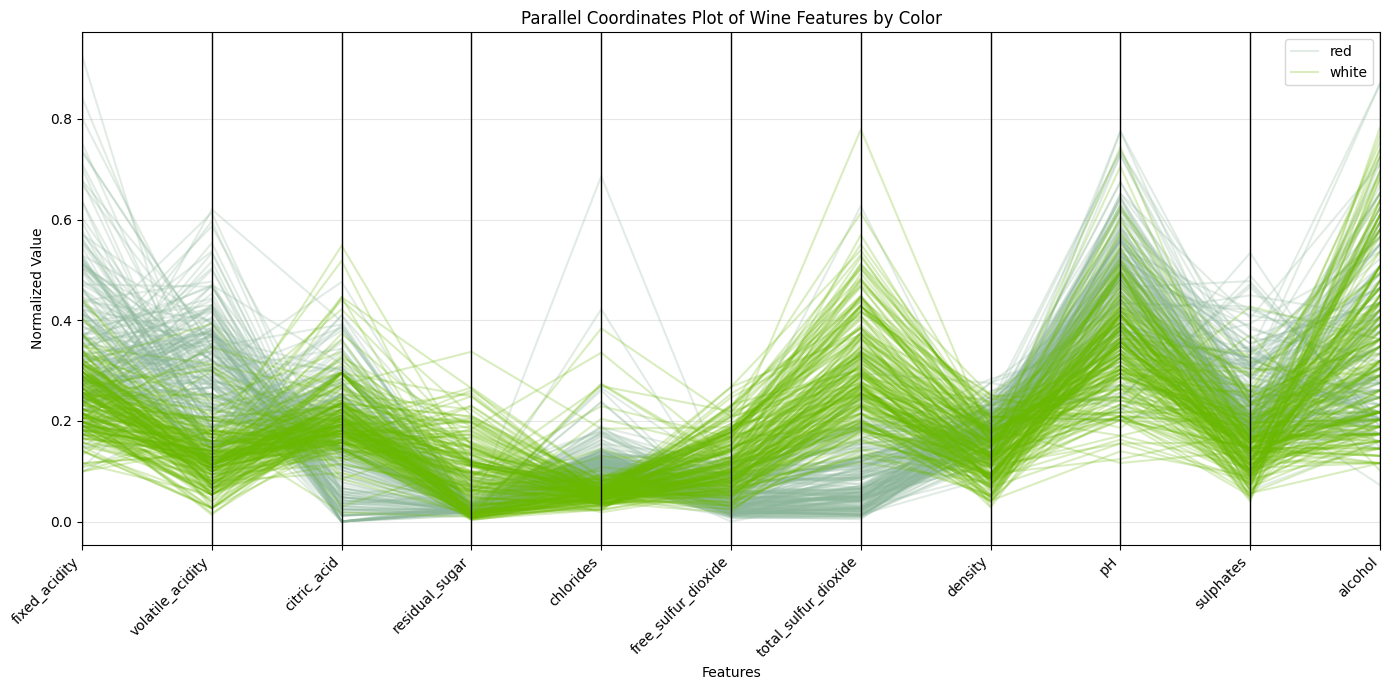

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pandas.plotting import parallel_coordinates
from sklearn.preprocessing import MinMaxScaler

# Select numeric columns for plotting
feature_cols = [
    "fixed_acidity",
    "volatile_acidity",
    "citric_acid",
    "residual_sugar",
    "chlorides",
    "free_sulfur_dioxide",
    "total_sulfur_dioxide",
    "density",
    "pH",
    "sulphates",
    "alcohol"
]

# Copy only needed columns
pc_df = df[feature_cols + ["color"]].copy()

# Normalize numeric features to [0, 1]
scaler = MinMaxScaler()
pc_df[feature_cols] = scaler.fit_transform(pc_df[feature_cols])

# Optional: sample rows so the plot does not get too crowded
# You can increase/decrease this depending on readability
pc_sample = (
    pc_df.groupby("color", group_keys=False)
    .apply(lambda x: x.sample(min(200, len(x)), random_state=42))
    .reset_index(drop=True)
)

# Create parallel coordinates plot
plt.figure(figsize=(14, 7))
parallel_coordinates(
    pc_sample,
    class_column="color",
    cols=feature_cols,
    alpha=0.25
)

plt.title("Parallel Coordinates Plot of Wine Features by Color")
plt.xlabel("Features")
plt.ylabel("Normalized Value")
plt.xticks(rotation=45, ha="right")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

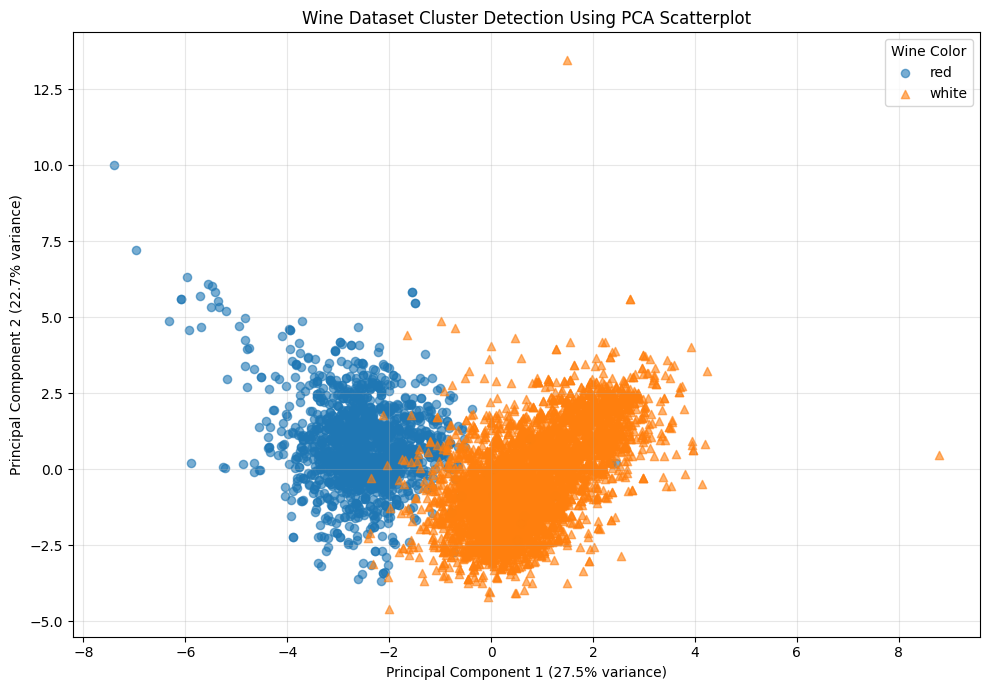

In [5]:
# Keep only numeric feature columns for PCA
numeric_cols = X.select_dtypes(include=[np.number]).columns
X_numeric = X[numeric_cols].copy()

# Standardize features so variables on bigger scales do not dominate PCA
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_numeric)

# Reduce to 2 dimensions
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Build plotting DataFrame
plot_df = pd.DataFrame(X_pca, columns=["PC1", "PC2"])
plot_df["color"] = df["color"].values
plot_df["quality"] = df["quality"].values

# Scatterplot for cluster detection
plt.figure(figsize=(10, 7))

for wine_color, marker in [("red", "o"), ("white", "^")]:
    subset = plot_df[plot_df["color"] == wine_color]
    plt.scatter(
        subset["PC1"],
        subset["PC2"],
        alpha=0.6,
        s=35,
        marker=marker,
        label=wine_color
    )

plt.title("Wine Dataset Cluster Detection Using PCA Scatterplot")
plt.xlabel(f"Principal Component 1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)")
plt.ylabel(f"Principal Component 2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)")
plt.legend(title="Wine Color")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

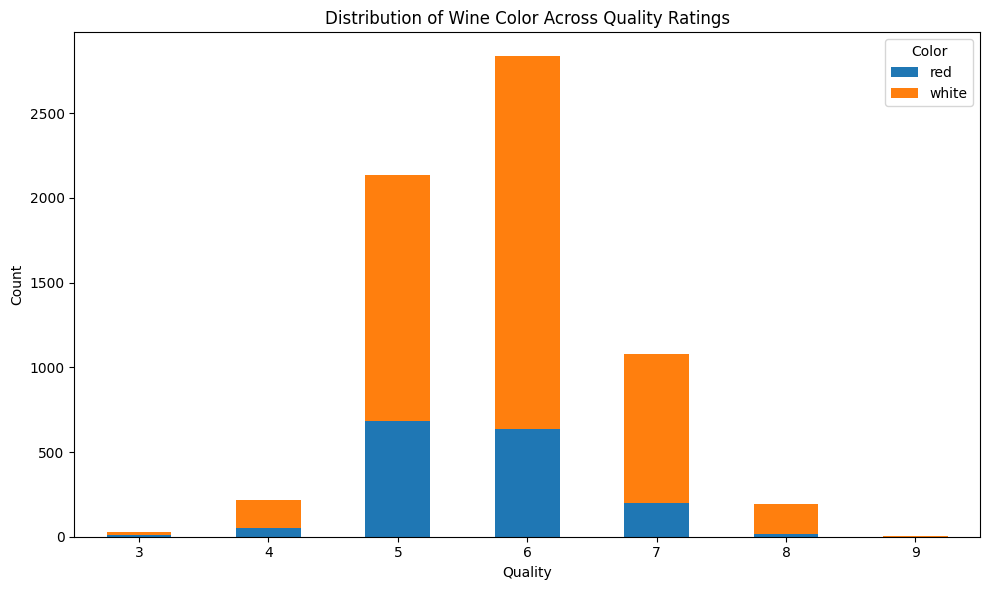

In [6]:
quality_color_counts = df.groupby(["quality", "color"]).size().unstack(fill_value=0)

quality_color_counts.plot(
    kind="bar",
    stacked=True,
    figsize=(10, 6)
)

plt.title("Distribution of Wine Color Across Quality Ratings")
plt.xlabel("Quality")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.legend(title="Color")
plt.tight_layout()
plt.show()

In [7]:
import seaborn as sns

corr = df[categories + ["quality"]].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(
    corr,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={'shrink': 0.8}
)
plt.title("Wine Quality - Feature Correlation Heatmap", size=14)
plt.tight_layout()
plt.show()

NameError: name 'categories' is not defined

In [ ]:
# fetch dataset
iris = fetch_ucirepo(id=53)
  
# data (as pandas dataframes)
X = iris.data.features
y = iris.data.targets

# metadata
print(iris.metadata)
  
# variable information
print(iris.variables)

df = X.copy()
df.columns = ['Sepal Length', 'Sepal Width', 'Petal Length', 'Petal Width']
df['Species'] = y['class']

plt.figure(figsize=(10, 6))
parallel_coordinates(df, 'Species', color=['#e41a1c', '#377eb8', '#4daf4a'], linewidth=0.8, alpha=0.6)
plt.title('Iris Dataset — Parallel Coordinates')
plt.ylabel('Value (cm)')
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()